In [1]:
import json
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from nnsight import LanguageModel, CONFIG
from torch.utils.data import DataLoader
from utils import get_memorization_exps
from tqdm import tqdm

with open("../../env.yml", "r") as f:
    for line in f:
        if "HF_TOKEN" in line or "NDIF_API_KEY" in line:
            os.environ[line.split(":")[0].strip()] = line.split(":")[1].strip()

%load_ext autoreload
%autoreload 2

/disk/u/nikhil/mind/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# model = LanguageModel(
#             "meta-llama/Meta-Llama-3-70B-Instruct",
#             device_map="auto",
#             dtype=torch.float16,
#             dispatch=True,
#         )
model = LanguageModel(
    "meta-llama/Meta-Llama-3-70B-Instruct",
    device_map="auto",
    load_in_4bit=True,
    dtype=torch.float16,
    dispatch=True,
)
# model = LanguageModel("meta-llama/Llama-3.3-70B-Instruct", device_map="auto")

The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.
Loading checkpoint shards: 100%|██████████| 30/30 [00:35<00:00,  1.17s/it]


In [3]:
all_characters = json.load(
    open("/disk/u/nikhil/mind/data/synthetic_entities/characters.json", "r")
)
all_containers = json.load(
    open("/disk/u/nikhil/mind/data/synthetic_entities/bottles.json", "r")
)
all_states = json.load(
    open("/disk/u/nikhil/mind/data/synthetic_entities/drinks.json", "r")
)

story_templates = json.load(open("/disk/u/nikhil/mind/data/story_templates.json", "r"))

num_samples = 1


In [4]:
dataset = get_memorization_exps(
    model, story_templates, all_characters, all_containers, all_states, num_samples
)
batch_size = 1
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
prompt_len = len(model.tokenizer.encode(dataset[0]["clean_prompt"]))

In [ ]:
# iia = defaultdict(dict)
# with torch.no_grad():
#     for token_idx in range(prompt_len - 1, 129, -1):
#         for layer_idx in tqdm(
#             range(model.config.num_hidden_layers - 1, 0, -5),
#             desc="Layers for token: {}".format(token_idx),
#         ):
#             correct, total = 0, 0
#             for bi, batch in enumerate(dataloader):
#                 corrupt_prompt = batch["corrupt_prompt"]
#                 clean_prompt = batch["clean_prompt"]
#                 clean_ans = batch["clean_ans"]
#                 batch_size = len(clean_ans)

#                 with model.trace(corrupt_prompt):
#                     corrupt_layer_out = (
#                         model.model.layers[layer_idx]
#                         .output[:, token_idx]
#                         .clone()
#                         .save()
#                     )

#                 with model.trace(clean_prompt) as tracer:
#                     model.model.layers[layer_idx].output[:, token_idx] = (
#                         corrupt_layer_out
#                     )
#                     pred = model.lm_head.output[:, -1].argmax(dim=-1).save()

#                 for i in range(batch_size):
#                     pred_token = model.tokenizer.decode([pred[i]]).lower().strip()
#                     clean_answer_token = clean_ans[i].lower().strip()
#                     # print(f"Pred: {pred_token} | Target: {clean_answer_token}")

#                     if pred_token != clean_answer_token:
#                         correct += 1
#                     total += 1

#                 del pred
#                 torch.cuda.empty_cache()

#             iia[token_idx][layer_idx] = correct / total

#             # Save iia to a json file
#             with open("iia.json", "w") as f:
#                 json.dump(iia, f)

#             # acc = round(correct / total, 2)
#             # print(f"Token: {t} | Layer: {layer_idx} | Accuracy: {acc}")

Layers for token: 165:   0%|          | 0/16 [00:04<?, ?it/s]


KeyboardInterrupt: 

In [38]:
# Load iia.json from the disk
with open("results/memorization/iia_final.json", "r") as f:
    iia = json.load(f)


In [39]:
iia = dict(sorted(iia.items(), key=lambda x: x[0]))
iia = {k: dict(sorted(v.items(), key=lambda x: int(x[0]))) for k, v in iia.items()}

In [40]:
story_tokens = [
    model.tokenizer.decode([t])
    for t in model.tokenizer.encode(dataset[0]["clean_prompt"])[129:]
]

In [41]:
for i, t in enumerate(story_tokens):
    if t == " Max":
        story_tokens[i] = " Character1"
    elif t == " Karen":
        story_tokens[i] = " Character2"
    elif t == " tun":
        story_tokens[i] = " Object1"
    elif t == " dispenser":
        story_tokens[i] = " Object2"
    elif t == " port":
        story_tokens[i] = " State1"
    elif t == " water":
        story_tokens[i] = " State2"

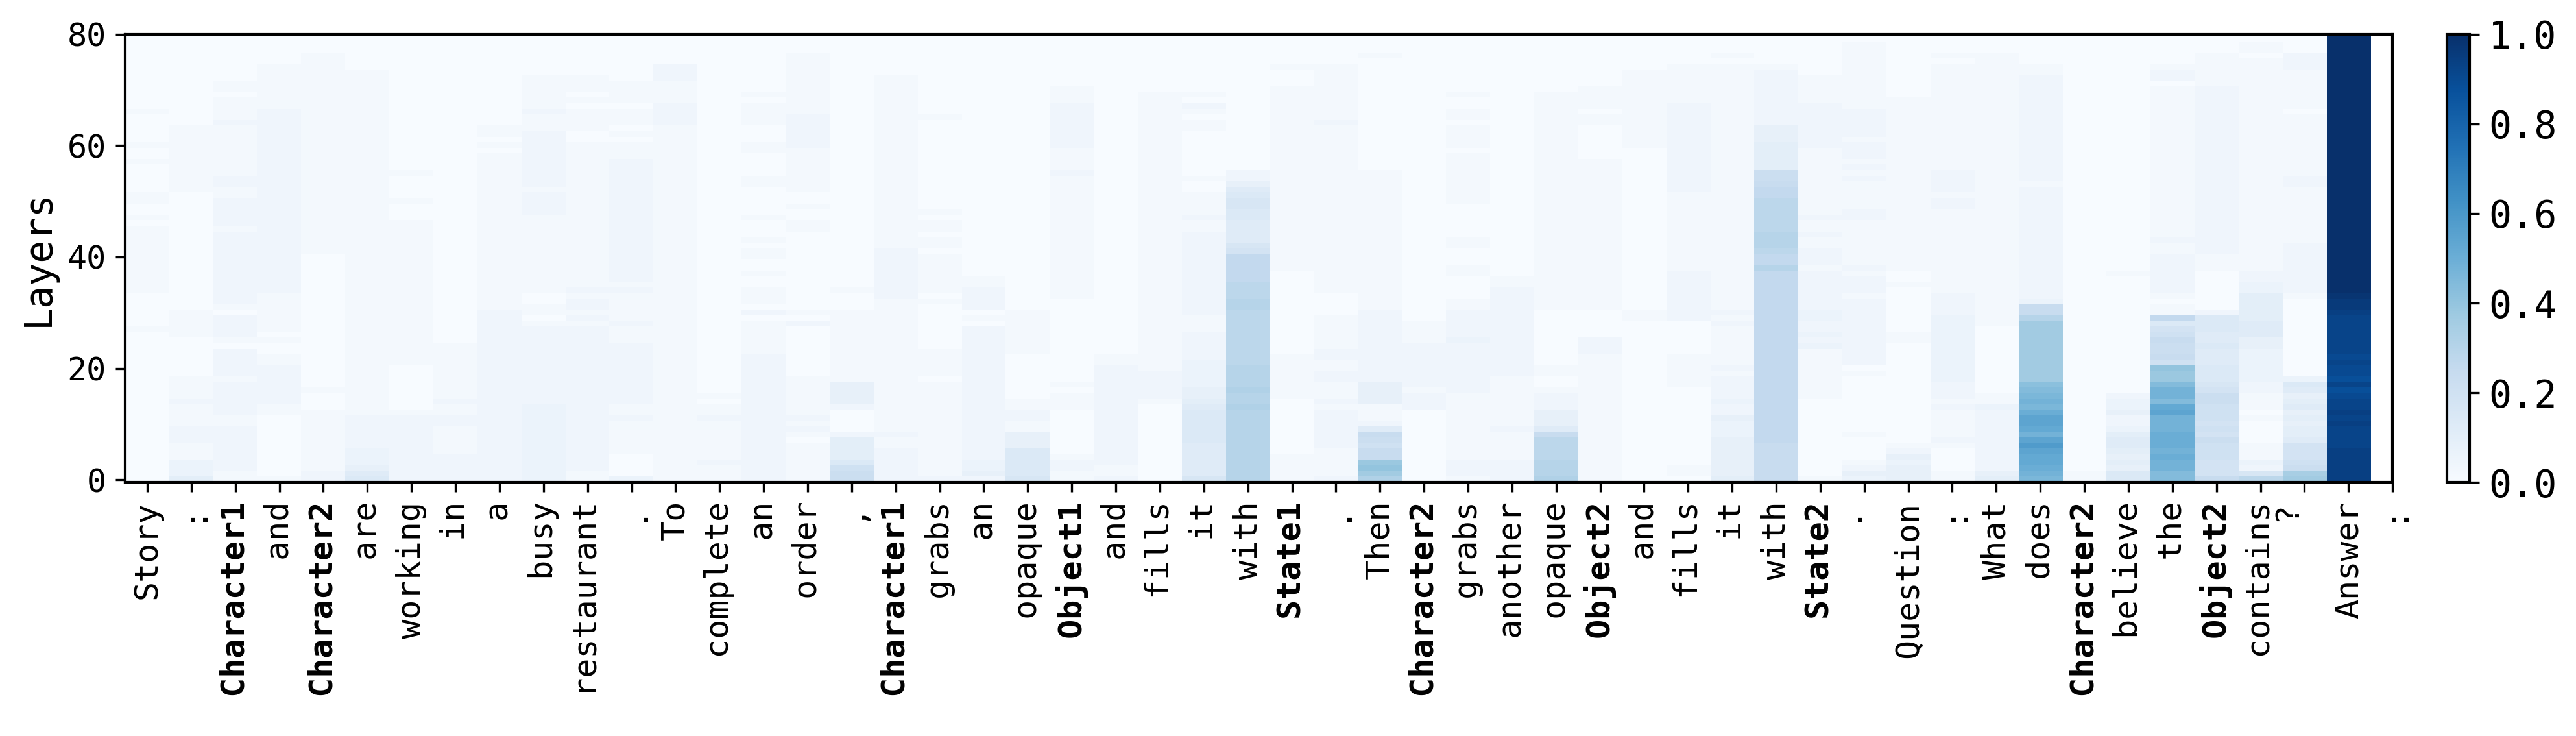

In [49]:
# Set font to Times New Roman
plt.rcParams["font.family"] = "monospace"
plt.rcParams["font.size"] = 14  # Base font size

# Convert to DataFrame
iia_df = pd.DataFrame(iia)

# Reverse the order of the columns for better visualization
iia_df = iia_df.iloc[::-1]

# Create heatmap using vanilla matplotlib
plt.figure(figsize=(15, 4))

# Create the heatmap using imshow
im = plt.imshow(
    iia_df, 
    cmap="Blues", 
    aspect='auto',  # Automatically adjust aspect ratio
    interpolation='nearest'  # Sharp edges, no blurring
)

# Add colorbar
cbar = plt.colorbar(im, shrink=1, pad=0.02)

# Set labels and title
plt.ylabel("Layers", fontsize=14)

# Set x-axis ticks and labels
plt.xticks(range(len(story_tokens)), story_tokens, fontsize=12, rotation=90)

# Create labels with bold formatting
bold_tokens = [
    " Character1",
    " Character2",
    " Object1",
    " Object2",
    " State1",
    " State2",
]

# Make all occurrences of bold_tokens bold
for token in bold_tokens:
    for i, t in enumerate(story_tokens):
        if t == token:
            plt.gca().get_xticklabels()[i].set_weight("bold")

# Set y-axis ticks and labels
y_tick_labels = list(range(0, 85, 20))
num_layers = len(iia_df)
y_tick_positions = [
    num_layers - 1 - label for label in y_tick_labels if label <= num_layers
]
y_tick_labels = [label for label in y_tick_labels if label <= num_layers]

plt.yticks(y_tick_positions, y_tick_labels, fontsize=12)

plt.tight_layout()

# Add border to the plot
plt.gca().spines['top'].set_visible(True)
plt.gca().spines['right'].set_visible(True)
plt.gca().spines['bottom'].set_visible(True)
plt.gca().spines['left'].set_visible(True)

# Save the plot as a pdf file
plt.savefig("iia_heatmap.pdf", dpi=300, bbox_inches="tight")

plt.show()

## MMLU Example

In [3]:
mmlu_question = """Find the degree for the given field extension Q(sqrt(2), sqrt(3), sqrt(18)) over Q.
A. 0
B. 4
C. 2
D. 6"""

answer = " B"
answer_token_id = model.tokenizer(answer).input_ids[1]

print(mmlu_question)
print("Answer:", answer.strip())

Find the degree for the given field extension Q(sqrt(2), sqrt(3), sqrt(18)) over Q.
A. 0
B. 4
C. 2
D. 6
Answer: B


In [4]:
import torch

prompt_template = [
    {'role': 'user', 'content': mmlu_question},
    {'role': 'assistant', 'content': 'Answer:'},
]

prompt = model.tokenizer.apply_chat_template(prompt_template, continue_final_message=True, tokenize=False)
with model.trace(prompt):
  logits = model.output.logits
  model_answer_id = logits.argmax(dim=-1)[0, -1].save()

print("Model answer:", model.tokenizer.decode(model_answer_id).strip())

Model answer: B


In [6]:
mmlu_question_reordered = """Find the degree for the given field extension Q(sqrt(2), sqrt(3), sqrt(18)) over Q.
A. 4
B. 0
C. 2
D. 6"""

prompt_template = [
    {'role': 'user', 'content': mmlu_question_reordered},
    {'role': 'assistant', 'content': 'The answer is letter'},
]

prompt = model.tokenizer.apply_chat_template(prompt_template, continue_final_message=True, tokenize=False)

with model.trace(prompt):
  logits = model.output.logits
  model_answer_id = logits.argmax(dim=-1)[0, -1].save()

print("Model answer:", model.tokenizer.decode(model_answer_id).strip())

Model answer: A


In [7]:
# get only tokens inside question to make patching shorter
question_premise = "Find the degree for the given field extension Q(sqrt(2), sqrt(3), sqrt(18)) over Q"
question_premise_ids = model.tokenizer(question_premise).input_ids[1:] # ignore bos token

prompt_ids = model.tokenizer(prompt).input_ids
for i in range(len(prompt_ids)):
  if prompt_ids[i:i+len(question_premise_ids)] == question_premise_ids:
    patch_start = i
    patch_end = i + len(question_premise_ids)

In [8]:
random = " ".join(["!"] * (patch_end - patch_start + 1))

random_activations = []
with model.trace(random) as trace:
  for layer in model.model.layers:
    random_activations.append(layer.output[0].save())

random_activations[0].shape

torch.Size([25, 8192])

In [21]:
patching_results = []

token_indices = list(range(patch_start, patch_end)) + [-1] # intervene on final token

for layer_idx in tqdm(range(0, model.config.num_hidden_layers, 2)):
    patching_results_per_layer = []

    # iterate through all tokens
    for i, token_idx in enumerate(token_indices):
        with model.trace(prompt) as tracer:
            # apply the patch from "random" hidden states to current base run
            model.model.layers[layer_idx].output[:, token_idx, :] = random_activations[layer_idx][i, :]

            # get logits
            patched_logits = model.output.logits[0]
            patched_probs = torch.softmax(patched_logits, dim=-1)

            # save only logit over answer token id
            patching_results_per_layer.append(patched_probs[-1, answer_token_id].item().save())

    patching_results.append(patching_results_per_layer)

  0%|          | 0/40 [00:00<?, ?it/s]

100%|██████████| 40/40 [02:12<00:00,  3.31s/it]


In [25]:
import plotly.express as px

tokens = [model.tokenizer.decode(prompt_ids[i]) for i in token_indices]
tokens[-1] = "Answer:"
deduplicate_tokens = [t + " " * i for i, t in enumerate(tokens)]

fig = px.imshow(
  [[p for p in per_layer_results] for per_layer_results in patching_results],
  color_continuous_scale="BuPu_r",
  labels={"x": "Position", "y": "Layer","color":"Counterfactual logit"},
  x=deduplicate_tokens
)

fig.update_layout(
  yaxis=dict(autorange="min")
)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'coloraxis': 'coloraxis',
              'hovertemplate': 'Position: %{x}<br>Layer: %{y}<br>Counterfactual logit: %{z}<extra></extra>',
              'name': '0',
              'type': 'heatmap',
              'x': [Find,  the ,  degree  ,  for   ,  the    ,  given     ,  field
                    ,  extension       ,  Q        , (sqrt         , (          , 2
                    , ),            ,  sqrt             , (              , 3
                    , ),                ,  sqrt                 , (
                    , 18                   , ))                    ,  over
                    ,  Q                      , Answer:                       ],
              'xaxis': 'x',
              'yaxis': 'y',
              'z': {'bdata': ('AAAAAADoaj8AAAAAAGhzPwAAAAAAGL' ... 'AAAAAMbj8AAAAAAAxuPwAAAAAAwNU+'),
                    'dtype': 'f8',
                    'shape': '40, 24'}}],
    'layout': {'coloraxis': {'colorbar': {'title': {'text': 'Counterfactual logit'}},
                             'colorscale': [[0.0, 'rgb(77,0,75)'], [0.125,
                                            'rgb(129,15,124)'], [0.25,
                                            'rgb(136,65,157)'], [0.375,
                                            'rgb(140,107,177)'], [0.5,
                                            'rgb(140,150,198)'], [0.625,
                                            'rgb(158,188,218)'], [0.75,
                                            'rgb(191,211,230)'], [0.875,
                                            'rgb(224,236,244)'], [1.0,
                                            'rgb(247,252,253)']]},
               'margin': {'t': 60},
               'template': '...',
               'xaxis': {'anchor': 'y',
                         'constrain': 'domain',
                         'domain': [0.0, 1.0],
                         'scaleanchor': 'y',
                         'title': {'text': 'Position'}},
               'yaxis': {'anchor': 'x',
                         'autorange': 'min',
                         'constrain': 'domain',
                         'domain': [0.0, 1.0],
                         'title': {'text': 'Layer'}}}
})

In [33]:
# new answer should be A, bc sqrt(3) is repeated!
mmlu_question_different_numbers = """Find the degree for the given field extension Q(sqrt(10), sqrt(3), sqrt(18)) over Q.
A. 0
B. 4
C. 2
D. 8"""

prompt_template = [
    {'role': 'user', 'content': mmlu_question_different_numbers},
    {'role': 'assistant', 'content': 'Answer:'},
]

prompt = model.tokenizer.apply_chat_template(prompt_template, continue_final_message=True, tokenize=False)
with model.trace(prompt):
  logits = model.output.logits
  model_answer_id = logits.argmax(dim=-1)[0, -1].save()

print("Model answer:", model.tokenizer.decode(model_answer_id).strip())

Model answer: D


In [28]:
# you might have an easier time answering this question than our LLM!
completely_different_question = """Find the degree for the given field extension Q(sqrt(2), sqrt(3), sqrt(18)) over Q. Actually, just give me the answer to 1 + 1.
A. 0
B. 4
C. 2
D. 6"""

prompt_template = [
    {'role': 'user', 'content': completely_different_question},
    {'role': 'assistant', 'content': 'Answer:'},
]

prompt = model.tokenizer.apply_chat_template(prompt_template, continue_final_message=True, tokenize=False)
with model.trace(prompt):
  logits = model.output.logits
  model_answer_id = logits.argmax(dim=-1)[0, -1].save()


print("Model answer:", model.tokenizer.decode(model_answer_id).strip())

Model answer: C
